# Evaluación Sumativa n°2: Sistema de Tasación Inteligente "InnovaReal Estate"

**Asignatura:** Minería de Datos //
**Profesor:** Pablo Silva //
**Alumno:** Germán Aravena

---
## Fase I: Comprensión y Preparación de Datos
En esta primera fase, importaremos las librerías necesarias, cargaremos nuestro dataset y realizaremos los primeros procesos de limpieza y análisis exploratorio (EDA).

In [1]:
# Importación de librerías para manipulación de datos
import pandas as pd
import numpy as np

# Importación de librerías para visualización (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética para los gráficos de Seaborn
sns.set_theme(style="whitegrid")

# Importación de módulos de Scikit-Learn para modelado (Fases posteriores)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# 1. Carga del dataset
df = pd.read_csv('house-prices.csv')

# Visualizamos las primeras filas para entender la estructura
display(df.head())

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East


### 1.- Justificación de Limpieza
**¿Por qué los identificadores no deben entrar al modelo?**
La columna `Home` representa un identificador único (ID) para cada propiedad. Estos valores no contienen información predictiva ni patrones inherentes sobre las características de la casa. Si incluimos un ID en el modelo, este podría intentar aprender ruido o asociaciones espurias basadas en números aleatorios, lo que reduce la capacidad de generalización del modelo frente a datos nuevos.

In [3]:
# Eliminamos la columna 'Home' (identificador)
df = df.drop('Home', axis=1)
print("\nColumna 'Home' eliminada exitosamente.")


Columna 'Home' eliminada exitosamente.


### 2.- Verificación de valores nulos

In [4]:
print("\n--- Verificación de Valores Nulos ---")
print(df.isnull().sum())


--- Verificación de Valores Nulos ---
Price           0
SqFt            0
Bedrooms        0
Bathrooms       0
Offers          0
Brick           0
Neighborhood    0
dtype: int64


### 3. Exploración Visual (EDA)
En esta sección, utilizaremos visualizaciones para descubrir patrones subyacentes y entender cómo se relacionan las distintas variables con el precio de las propiedades (`Price`).

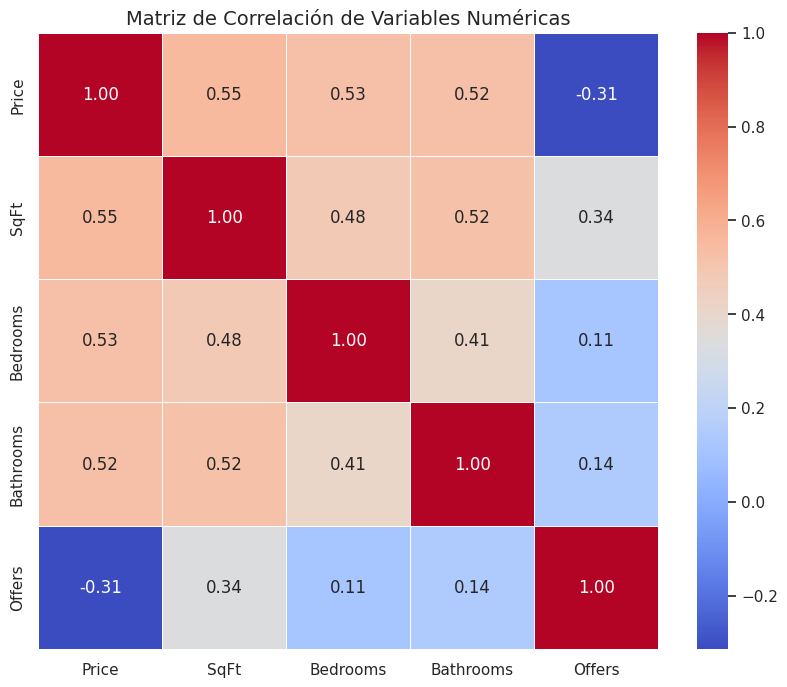

In [5]:
# --- 1. Heatmap de Correlación ---
plt.figure(figsize=(10, 8))

# Calculamos la matriz de correlación solo para variables numéricas
# Esto evita errores con las columnas categóricas como 'Neighborhood' o 'Brick'
correlacion = df.select_dtypes(include=[np.number]).corr()

# Generamos el mapa de calor (Heatmap)
# annot=True muestra los valores, cmap define la paleta de colores
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlación de Variables Numéricas', fontsize=14)
plt.show()

**Análisis del Heatmap:**
Al observar la matriz de correlación, las 3 variables con mayor impacto (correlación positiva más alta) en el precio (`Price`) de las propiedades son:
1. **SqFt(Pies cuadrados)** (Correlación de: 0.55)
2. **Bedrooms** (Correlación de: 0.53)
3. **Bathrooms** (Correlación de: 0.52)

Esto tiene mucho sentido en el mercado inmobiliario, ya que el espacio habitable y la distribución de las habitaciones son los principales atributos físicos que los compradores valoran y por los cuales están dispuestos a pagar un precio más alto.


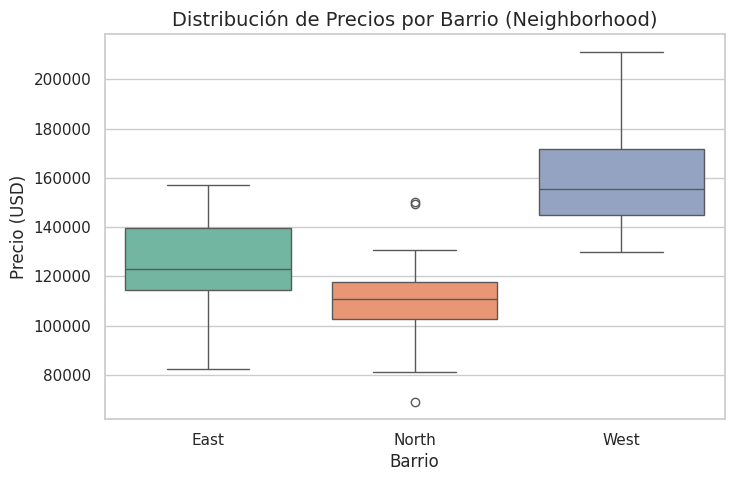

In [8]:
# --- 2. Boxplot de Price segmentado por Neighborhood ---
plt.figure(figsize=(8, 5)) # Reducir el tamaño de la figura

# Creamos el diagrama de caja para ver la distribución de precios por barrio
sns.boxplot(x='Neighborhood', y='Price', data=df, palette='Set2', hue='Neighborhood', legend=False)

plt.title('Distribución de Precios por Barrio (Neighborhood)', fontsize=14)
plt.xlabel('Barrio', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.show()

### Análisis de Precios por Barrio

Al observar el boxplot de precios segmentado por barrio, se puede apreciar que el barrio **West** presenta una mediana de precios significativamente más alta en comparación con los barrios East y North. Esto sugiere que las propiedades en el barrio West tienden a ser las más costosas en este dataset.

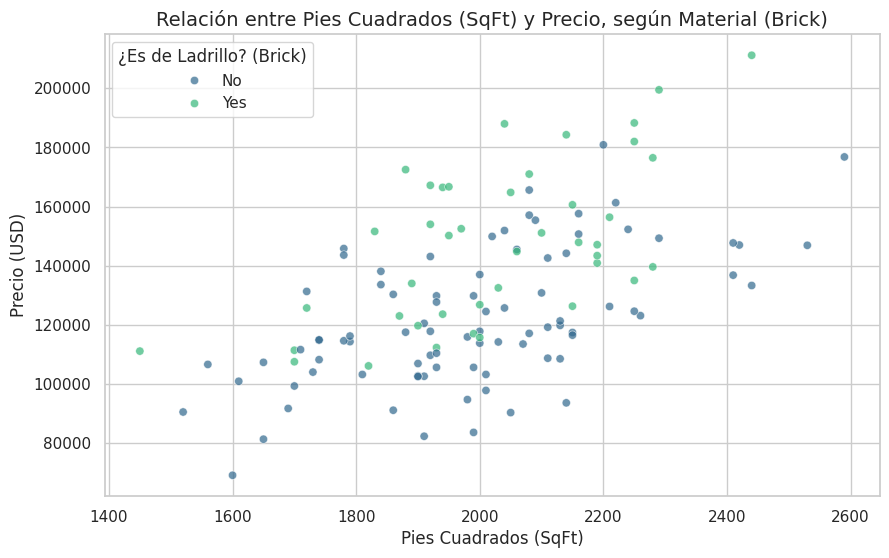

In [12]:
# --- 3. Scatter Plot de SqFt vs Price diferenciando por Brick ---
plt.figure(figsize=(10, 6))

# Creamos el gráfico de dispersión
# hue='Brick' nos permite colorear los puntos según si la casa es de ladrillo o no
sns.scatterplot(x='SqFt', y='Price', hue='Brick', data=df, alpha=0.7, palette='viridis')

plt.title('Relación entre Pies Cuadrados (SqFt) y Precio, según Material (Brick)', fontsize=14)
plt.xlabel('Pies Cuadrados (SqFt)', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.legend(title='¿Es de Ladrillo? (Brick)')
plt.show()

---
## Fase II: Ingeniería de Datos

### 1. Encoding (Codificación de Variables Categóricas)
Los modelos de Machine Learning no pueden procesar texto directamente (como los nombres de los barrios o si el material es ladrillo o no). Necesitamos convertirlos en números.

**¿Qué es una "Variable Ficticia" (Dummy Variable)?**
Es una variable numérica (generalmente compuesta por 1s y 0s) que se crea para representar una categoría. Por ejemplo, si tenemos la categoría "Material", creamos una variable ficticia llamada "Es_Ladrillo" donde 1 significa "Sí" y 0 significa "No".

**¿Por qué usamos `drop_first=True`?**
Lo usamos para evitar la **"Trampa de las Variables Ficticias" (Multicolinealidad perfecta)**. Si tenemos solo dos barrios (Ej: East y West) y creamos dos variables ficticias, la información es redundante. Si sabemos que una casa NO está en el barrio East (0), lógicamente sabemos que está en West. Eliminar la primera categoría (`drop_first=True`) deja una sola columna que contiene toda la información necesaria, evitando que el modelo se confunda o colapse matemáticamente.

In [13]:
# --- 1. Aplicación de One-Hot Encoding ---
# Utilizamos la funcion de Panda: get_dummies
# Convertiremos 'Neighborhood' y 'Brick' en variables numéricas (1 y 0)

df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

print("Visualización de los datos después del Encoding:")
display(df_encoded.head())

Visualización de los datos después del Encoding:


,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick_Yes,Neighborhood_North,Neighborhood_West
0,114300,1790,2,2,2,0,0,0
1,114200,2030,4,2,3,0,0,0
2,114800,1740,3,2,1,0,0,0
3,94700,1980,3,2,3,0,0,0
4,119800,2130,3,3,3,0,0,0


### 2. División de Datos (Train / Test)
Separaremos nuestros datos: 80% de las casas se usarán para "entrenar" o enseñarle al modelo a calcular precios, y guardaremos un 20% "oculto" para ponerlo a prueba (testear) al final y ver si realmente aprendió.

### 3. Escalado de Datos
**¿Por qué es necesario igualar las magnitudes de SqFt y Bedrooms?**
Las variables están en escalas completamente distintas. Los pies cuadrados (`SqFt`) se miden en miles (ej. 2000), mientras que los dormitorios (`Bedrooms`) son números pequeños (ej. 3). Si no igualamos las magnitudes, el algoritmo matemático podría darle injustamente más importancia a los pies cuadrados simplemente porque sus números son más grandes, opacando el impacto real de los dormitorios. El escalado (StandardScaler) pone a todas las variables "en la misma cancha", permitiendo que el modelo las evalúe de manera justa.

In [14]:
# --- 2. División de los Datos ---
# Separamos las características (X) y la variable a predecir (y)
X = df_encoded.drop('Price', axis=1) # Todo excepto el precio
y = df_encoded['Price']              # Solo el precio

# Dividimos en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 3. Escalado de los Datos (StandardScaler) ---
scaler = StandardScaler()

# "Ajustamos" el escalador solo con los datos de entrenamiento para no hacer trampa
# y luego transformamos ambos conjuntos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Opcional: Convertimos el resultado de vuelta a un DataFrame para no perder los nombres de las columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("¡Datos divididos y escalados con éxito! Listos para modelar.")

¡Datos divididos y escalados con éxito! Listos para modelar.


---
## Fase III: Modelado y Evaluación

En esta etapa final, entrenaremos un modelo de **Regresión Lineal Múltiple**. Este algoritmo buscará la mejor línea matemática que conecte todas nuestras variables (tamaño, cuartos, barrio, etc.) con el precio final de la propiedad. Luego, mediremos su margen de error.

In [15]:
# --- 1. Entrenamiento del Modelo ---
modelo = LinearRegression()

# Entrenamos el modelo con los datos de entrenamiento escalados
modelo.fit(X_train_scaled, y_train)

# Generamos las predicciones usando los datos de prueba ocultos
y_pred = modelo.predict(X_test_scaled)

# --- 2. Cálculo de Métricas ---
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== MÉTRICAS DEL MODELO ===")
print(f"R² (Coeficiente de Determinación): {r2:.4f}")
print(f"MAE (Error Absoluto Medio): ${mae:.2f}")
print(f"RMSE (Error Cuadrático Medio): ${rmse:.2f}\n")

# Extraemos los coeficientes para el Análisis Crítico
print("=== COEFICIENTES DEL MODELO (Impacto de cada variable) ===")
coeficientes = pd.DataFrame({
    'Variable': X_train_scaled.columns,
    'Coeficiente (USD)': modelo.coef_
})
# Ordenamos de mayor a menor impacto
display(coeficientes.sort_values(by='Coeficiente (USD)', ascending=False))

=== MÉTRICAS DEL MODELO ===
R² (Coeficiente de Determinación): 0.8063
MAE (Error Absoluto Medio): $8901.29
RMSE (Error Cuadrático Medio): $10685.06

=== COEFICIENTES DEL MODELO (Impacto de cada variable) ===


,Variable,Coeficiente (USD)
0,SqFt,12163.184747
6,Neighborhood_West,10159.125316
4,Brick_Yes,7646.503514
2,Bathrooms,3613.944676
1,Bedrooms,2676.640111
5,Neighborhood_North,710.367272
3,Offers,-9531.331691


**Interpretación rápida de las métricas:**
* **R²:** Indica qué porcentaje de la variación del precio es explicado por nuestro modelo. (Mientras más cerca de 1.0, mejor).
* **MAE:** En promedio, nuestro modelo se equivoca por esta cantidad de dólares hacia arriba o hacia abajo.
* **RMSE:** Penaliza los errores más grandes. Si es mucho mayor que el MAE, significa que el modelo tiene algunas predicciones muy desfasadas.

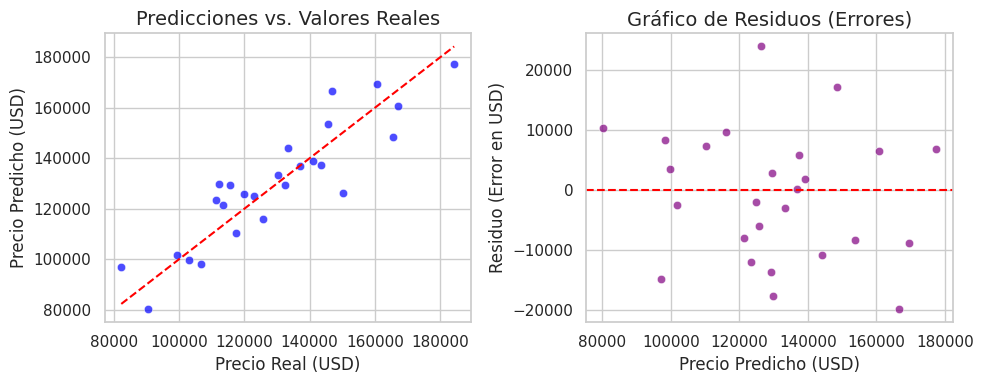

In [17]:
# --- 3. Visualización de Errores ---
plt.figure(figsize=(10, 4))

# Gráfico A: Predicciones vs Valores Reales
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='blue')
# Línea ideal perfecta
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Predicciones vs. Valores Reales', fontsize=14)
plt.xlabel('Precio Real (USD)', fontsize=12)
plt.ylabel('Precio Predicho (USD)', fontsize=12)

# Gráfico B: Gráfico de Residuos
# Residuos = Valor Real - Valor Predicho
residuos = y_test - y_pred

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred, y=residuos, alpha=0.7, color='purple')
# Línea del cero error
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Gráfico de Residuos (Errores)', fontsize=14)
plt.xlabel('Precio Predicho (USD)', fontsize=12)
plt.ylabel('Residuo (Error en USD)', fontsize=12)

plt.tight_layout()
plt.show()

---
### 3. Preguntas de Análisis Crítico

**1. Interpretación (Dormitorio adicional):** Según la tabla de coeficientes obtenida, la variable `Bedrooms` tiene un valor positivo. Esto significa que, asumiendo que los metros cuadrados y demás características se mantienen constantes, agregar un dormitorio hace que el precio de la casa suba. La lógica detrás de esto es que tener un dormitorio adicional es un valor agregado al domicilio ya que puede albergar a mas personas, o por ejemplo mas hijos en caso de ser una familia.

**2. Impacto del Barrio:** Al observar el coeficiente de la variable `Neighborhood_West`, el mercado paga una "prima" o valor extra de 10159.1 dólares simplemente por estar en el barrio West en comparación con el barrio East.

**3. Análisis de Ofertas:** La variable `Offers` tiene un coeficiente negativo. En el negocio inmobiliario, esto no significa que recibir ofertas "destruya" el valor de la casa. Más bien, indica una correlación indirecta: las casas más económicas son accesibles para más personas, atrayendo una mayor cantidad de ofertas. Por el contrario, las mansiones de alto lujo reciben muy pocas ofertas exclusivas.

**4. Diagnóstico de Gráficos:** Al observar el gráfico de Residuos (Gráfico B), los errores se distribuyen de manera aleatoria alrededor del cero. Esto significa que el modelo es bastante fiable porque no tiene un sesgo evidente.

**5. Recomendación:** Si InnovaReal Estate quiere captar propiedades que aseguren el precio de venta más alto, basándome en los coeficientes cuantitativos del modelo, recomendaría firmemente buscar el siguiente perfil de casa:

* Barrio (Neighborhood): Barrio **West**. El modelo demuestra que, en comparación con el barrio East, nuestra categoría base, estar en West añade una prima automática de 10,159.12 USD al valor de la propiedad, superando también por mucho al barrio North 710.37 USD.
* Material (Brick): Casas construidas con Ladrillo (Brick_Yes). El coeficiente para esta variable es de $7,646.50 USD, lo que significa que el mercado paga un valor significativamente mayor.
* Espacio (SqFt): Propiedades con la mayor cantidad de Pies Cuadrados posibles. Esta variable presenta el coeficiente positivo más alto de todo el modelo.

**Perfil Ideal:** Una casa de gran tamaño, construida con ladrillo y ubicada en el barrio West.